<a href="https://colab.research.google.com/github/NIKUNJ-PROGRAMMER/PRE-PLACEMENT/blob/main/CAPSTONE_PROJECT(NETLFIX).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CAPSTONE PROJECT(NETLFIX)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Ratings parsed: (24053764, 3)
Movie catalog loaded: (17770, 3)

Total ratings: 24053764
Unique movies rated: 4499
Unique customers: 470758
Rating
1    1118186
2    2439073
3    6904181
4    8085741
5    5506583
Name: count, dtype: int64


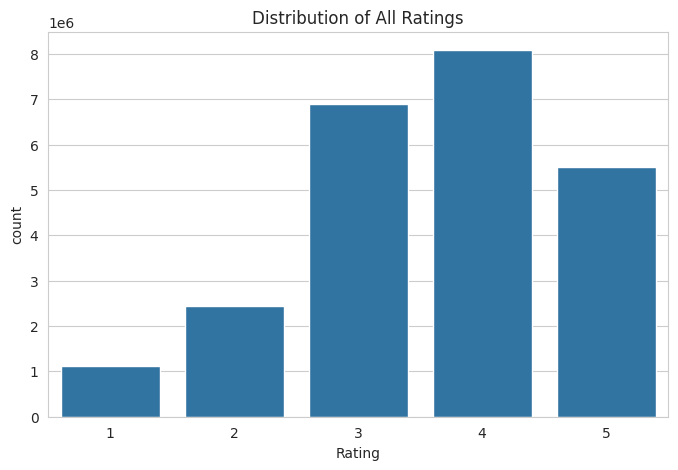


Most popular (most-rated) movies:
                                                   Name    Year  Num_Ratings  \
1904  Pirates of the Caribbean: The Curse of the Bla...  2003.0       193941   
2151                                    What Women Want  2000.0       162597   
3859                                     Bruce Almighty  2003.0       160454   
4431                                    The Italian Job  2003.0       156183   
570                                     American Beauty  1999.0       154832   
3937                                            Shrek 2  2004.0       153996   
4305                                    The Sixth Sense  1999.0       151292   
2451      Lord of the Rings: The Fellowship of the Ring  2001.0       149866   
1961                                     50 First Dates  2004.0       145519   
3961                          Finding Nemo (Widescreen)  2003.0       140979   

      Avg_Rating  
1904    4.153908  
2151    3.425322  
3859    3.434517  
4431    

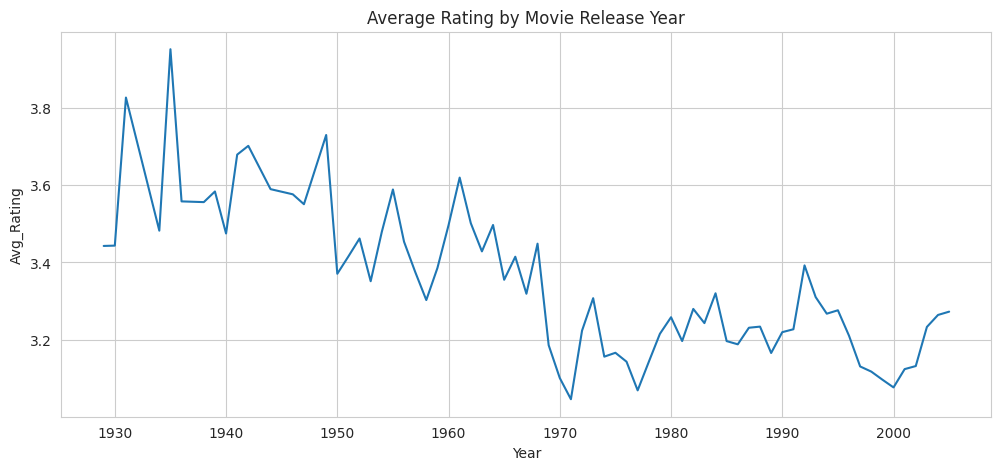


Best rated years:
       Year  Num_Ratings  Avg_Rating
18  1935.0        13282    3.950539
14  1931.0        11418    3.825707
32  1949.0        21111    3.729123
25  1942.0        17578    3.701078
24  1941.0        49495    3.678394

Worst rated years:
       Year  Num_Ratings  Avg_Rating
54  1971.0        30244    3.046911
60  1977.0        25377    3.069771
83  2000.0      1248683    3.077383
82  1999.0      1216675    3.097368
53  1970.0        20857    3.101641

Before filtering: (24053764, 3)  After filtering: (17337458, 3)

Example 'movies like this' recommendation:
          Correlation  Num_Ratings  \
Movie_Id                             
3            1.000000         2012   
579          0.714448         2047   
2335         0.713041         1947   
988          0.712606         1839   
2019         0.693215         2000   
2080         0.691037         1931   
3733         0.686939         2624   
2405         0.681311         1891   
774          0.681279         2475   


In [2]:
ratings_path = '/content/drive/MyDrive/Netflix_Dataset/combined_data_1.txt'
titles_path = '/content/drive/MyDrive/Netflix_Dataset/movie_titles (1).csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

sns.set_style('whitegrid')

!pip install scikit-surprise --quiet

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as svd_split


df = pd.read_csv(ratings_path, header=None, names=['Cust_Id', 'Rating', 'Date'], usecols=[0, 1, 2])
df['Rating'] = df['Rating'].astype(float)

df_nan = pd.DataFrame(pd.isnull(df.Rating))
df_nan = df_nan[df_nan['Rating'] == True].reset_index()

movie_np = []
movie_id = 1
for i, j in zip(df_nan['index'][1:], df_nan['index'][:-1]):
    movie_np = np.append(movie_np, np.full((1, i - j - 1), movie_id))
    movie_id += 1
movie_np = np.append(movie_np, np.full((1, len(df) - df_nan.iloc[-1, 0] - 1), movie_id))

df = df[pd.notnull(df['Rating'])].copy()
df['Movie_Id'] = movie_np.astype(np.int16)
df['Cust_Id'] = df['Cust_Id'].astype(np.int32)
df['Rating'] = df['Rating'].astype(np.int8)
df = df.drop('Date', axis=1)

del movie_np, df_nan
gc.collect()

print("Ratings parsed:", df.shape)


rows = []
with open(titles_path, encoding='ISO-8859-1') as f:
    for line in f:
        parts = line.rstrip('\n').split(',', 2)
        if len(parts) == 3:
            rows.append(parts)

movie_titles = pd.DataFrame(rows, columns=['Movie_Id', 'Year', 'Name'])
movie_titles['Movie_Id'] = movie_titles['Movie_Id'].astype(np.int16)
movie_titles['Year'] = pd.to_numeric(movie_titles['Year'], errors='coerce')

print("Movie catalog loaded:", movie_titles.shape)


print("\nTotal ratings:", len(df))
print("Unique movies rated:", df['Movie_Id'].nunique())
print("Unique customers:", df['Cust_Id'].nunique())
print(df['Rating'].value_counts().sort_index())


plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df)
plt.title('Distribution of All Ratings')
plt.show()


movie_counts = df.groupby('Movie_Id')['Rating'].count().reset_index().rename(columns={'Rating': 'Num_Ratings'})
movie_avg = df.groupby('Movie_Id')['Rating'].mean().reset_index().rename(columns={'Rating': 'Avg_Rating'})
movie_stats = movie_counts.merge(movie_avg, on='Movie_Id').merge(movie_titles, on='Movie_Id')

print("\nMost popular (most-rated) movies:")
print(movie_stats.sort_values('Num_Ratings', ascending=False).head(10)[['Name', 'Year', 'Num_Ratings', 'Avg_Rating']])

min_ratings = 1000
qualified = movie_stats[movie_stats['Num_Ratings'] >= min_ratings]
print("\nBest-liked movies (avg rating, min 1000 ratings):")
print(qualified.sort_values('Avg_Rating', ascending=False).head(10)[['Name', 'Year', 'Num_Ratings', 'Avg_Rating']])


year_stats = movie_stats.groupby('Year').agg(
    Num_Ratings=('Num_Ratings', 'sum'),
    Avg_Rating=('Avg_Rating', 'mean')
).reset_index()
year_stats = year_stats[year_stats['Num_Ratings'] >= 5000]

plt.figure(figsize=(12, 5))
sns.lineplot(data=year_stats.sort_values('Year'), x='Year', y='Avg_Rating')
plt.title('Average Rating by Movie Release Year')
plt.show()

print("\nBest rated years:\n", year_stats.sort_values('Avg_Rating', ascending=False).head(5))
print("\nWorst rated years:\n", year_stats.sort_values('Avg_Rating').head(5))


movie_summary = df.groupby('Movie_Id')['Rating'].count()
movie_benchmark = movie_summary.quantile(0.7)
drop_movie_list = movie_summary[movie_summary < movie_benchmark].index

cust_summary = df.groupby('Cust_Id')['Rating'].count()
cust_benchmark = cust_summary.quantile(0.7)
drop_cust_list = cust_summary[cust_summary < cust_benchmark].index

df_filtered = df[~df['Movie_Id'].isin(drop_movie_list)]
df_filtered = df_filtered[~df_filtered['Cust_Id'].isin(drop_cust_list)]

print('\nBefore filtering:', df.shape, ' After filtering:', df_filtered.shape)


p = df_filtered.pivot_table(index='Cust_Id', columns='Movie_Id', values='Rating')

def recommend_similar(movie_title, min_ratings=300, top_n=10):
    match = movie_titles[movie_titles['Name'] == movie_title]
    if match.empty:
        return f"'{movie_title}' not found in catalog."
    movie_id = match['Movie_Id'].values[0]
    if movie_id not in p.columns:
        return f"'{movie_title}' was filtered out in Step 7 (too few ratings)."

    target_ratings = p[movie_id]
    similarity = p.corrwith(target_ratings)
    corr_df = pd.DataFrame(similarity, columns=['Correlation']).dropna()
    corr_df = corr_df.join(movie_counts.set_index('Movie_Id'))
    corr_df = corr_df[corr_df['Num_Ratings'] >= min_ratings]
    corr_df = corr_df.join(movie_titles.set_index('Movie_Id')[['Name', 'Year']])
    return corr_df.sort_values('Correlation', ascending=False).head(top_n)

print("\nExample 'movies like this' recommendation:")
print(recommend_similar("Character"))


reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_filtered[['Cust_Id', 'Movie_Id', 'Rating']], reader)
trainset, testset = svd_split(data, test_size=0.2, random_state=42)

svd = SVD(n_factors=50, random_state=42)
svd.fit(trainset)

preds = svd.test(testset)
print("\nSVD model RMSE:", accuracy.rmse(preds))
print("SVD model MAE:", accuracy.mae(preds))


all_movie_ids = df_filtered['Movie_Id'].unique()

def recommend_for_customer(cust_id, top_n=10):
    rated_movies = set(df_filtered[df_filtered['Cust_Id'] == cust_id]['Movie_Id'])
    candidates = [m for m in all_movie_ids if m not in rated_movies]

    predictions = [(m, svd.predict(cust_id, m).est) for m in candidates]
    predictions.sort(key=lambda x: x[1], reverse=True)

    result = pd.DataFrame(predictions[:top_n], columns=['Movie_Id', 'Predicted_Rating'])
    result = result.merge(movie_titles, on='Movie_Id')
    return result[['Name', 'Year', 'Predicted_Rating']]

sample_customer = df_filtered['Cust_Id'].iloc[0]
print(f"\nTop recommendations for customer {sample_customer}:")
print(recommend_for_customer(sample_customer))